In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

df1 = pd.read_csv('https://drive.google.com/uc?id=1uS9RWDynfsAApIrubLP5syxrJtcEk9po')
df2 = pd.read_csv('https://drive.google.com/uc?id=1y5lP2RtFRborRCU6g24m7frzMfQxvxMr')

In [ ]:
df1['date'] = pd.to_datetime(df1['date'])

In [ ]:
df1.head()

,state,county,age_group,gender,date,cases,deaths,recovered
0,Baden-Wuerttemberg,LK Alb-Donau-Kreis,00-04,F,2020-03-27,1,0,1
1,Baden-Wuerttemberg,LK Alb-Donau-Kreis,00-04,F,2020-03-28,1,0,1
2,Baden-Wuerttemberg,LK Alb-Donau-Kreis,00-04,F,2020-04-03,1,0,1
3,Baden-Wuerttemberg,LK Alb-Donau-Kreis,00-04,F,2020-10-18,1,0,1
4,Baden-Wuerttemberg,LK Alb-Donau-Kreis,00-04,F,2020-10-22,1,0,1


In [ ]:
df2.head()

,state,gender,age_group,population
0,Baden-Wuerttemberg,female,00-04,261674
1,Baden-Wuerttemberg,female,05-14,490822
2,Baden-Wuerttemberg,female,15-34,1293488
3,Baden-Wuerttemberg,female,35-59,1919649
4,Baden-Wuerttemberg,female,60-79,1182736


In [ ]:
df1.describe(include='all')

,state,county,age_group,gender,date,cases,deaths,recovered
count,691226,691226,688982,677310,691226,691226.000000,691226.000000,691226.000000
unique,16,412,6,2,NaN,NaN,NaN,NaN
top,Bayern,SK Muenchen,35-59,F,NaN,NaN,NaN,NaN
freq,151617,3869,180640,340272,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2020-11-21 16:36:58.624878336,4.210171,0.111975,3.781973
min,NaN,NaN,NaN,NaN,2020-01-07 00:00:00,0.000000,0.000000,-1.000000
25%,NaN,NaN,NaN,NaN,2020-10-19 00:00:00,1.000000,0.000000,1.000000
50%,NaN,NaN,NaN,NaN,2020-12-12 00:00:00,2.000000,0.000000,2.000000
75%,NaN,NaN,NaN,NaN,2021-02-04 00:00:00,5.000000,0.000000,4.000000
max,NaN,NaN,NaN,NaN,2021-04-06 00:00:00,207.000000,20.000000,207.000000


In [ ]:
df2.describe(include='all')

,state,gender,age_group,population
count,192,192,192,1.920000e+02
unique,16,2,6,NaN
top,Baden-Wuerttemberg,female,00-04,NaN
freq,12,96,32,NaN
mean,NaN,NaN,NaN,4.323917e+05
std,NaN,NaN,NaN,5.572337e+05
min,NaN,NaN,NaN,1.590600e+04
25%,NaN,NaN,NaN,9.545700e+04
50%,NaN,NaN,NaN,2.345960e+05
75%,NaN,NaN,NaN,4.841690e+05


In [ ]:
nan_df1 = np.sum(df1.isnull(), axis = 0)
nan_df2 = np.sum(df2.isnull(), axis = 0)
print(nan_df1)
print(nan_df2)
print(df1.shape)
print(f"{((2244+13916)/691226)*100:.2f}% of dataset 1 consists of missing values")

state            0
county           0
age_group     2244
gender       13916
date             0
cases            0
deaths           0
recovered        0
dtype: int64
state         0
gender        0
age_group     0
population    0
dtype: int64
(691226, 8)
2.34% of dataset 1 consists of missing values


Since the missing values make up less than 3% of the dataset(0.32% of age_group and 2% of gender is missing), their quantity is negligible compared to the remaining number of samples. Additionally, age group and gender are categorical values so they cannot benefit from mean or random imputation. For these reasons, they were dropped from the dataset.

In [ ]:
df1.dropna(subset=['age_group', 'gender'], inplace=True)
print(df1.isnull().sum())

state        0
county       0
age_group    0
gender       0
date         0
cases        0
deaths       0
recovered    0
dtype: int64


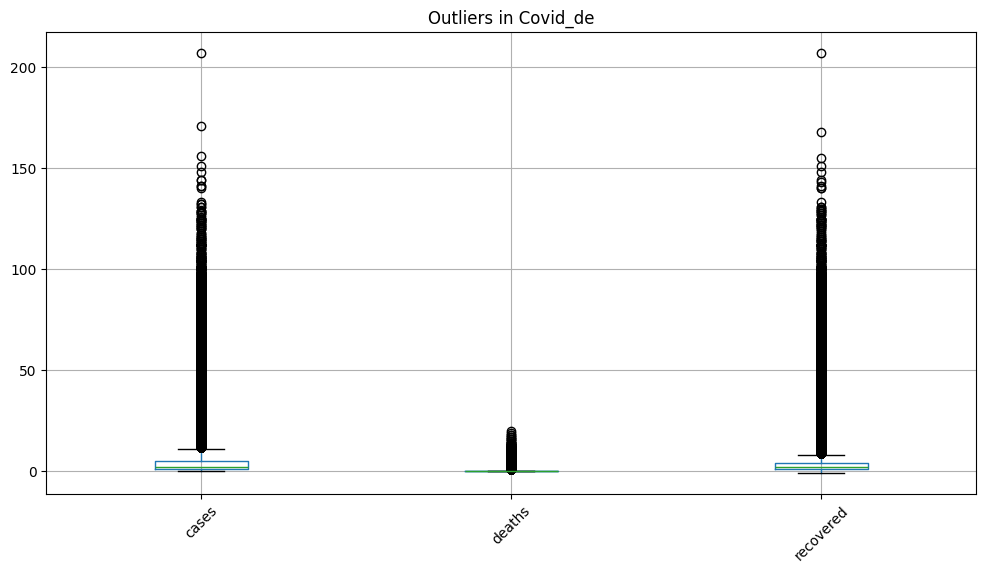

In [ ]:
#outlier processing here
#starting with boxplot to visualize outliers
df1.boxplot(figsize=(12,6))
plt.title("Outliers in Covid_de")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#stats_df1 = df1[['cases', 'recovered']].describe()
total_outliers = 0
for col in ['cases', 'deaths', 'recovered']:
  q1= df1[col].quantile(0.25)
  q3 = df1[col].quantile(0.75)
  IQR = q3-q1
  lower = q1-1.5 * IQR
  upper = q3+1.5 * IQR

  outliers = df1[(df1[col]<lower) | (df1[col]> upper)].shape[0]
  total_outliers += df1[(df1[col]<lower) | (df1[col]> upper)].shape[0]
  """
  print(f"{col}:")
  print(f"\tlower:{lower}")
  print(f"\tupper:{upper}")
  print(f"\toutlier count:{outliers}")
  """
print(total_outliers)
print(f"Percentage of total outliers: {(total_outliers/df1.shape[0]) * 100}")

175224
Percentage of total outliers: 25.93816844177664


In [ ]:
q1 = df1['cases'].quantile(0.25)
q3 = df1['cases'].quantile(0.75)
IQR = q3-q1
upper = q3+1.5 * IQR

outlier_rows =df1[df1['cases'] > upper]

print(outlier_rows['age_group'].value_counts())
print(outlier_rows['state'].value_counts().head(10))
df1['date'] = pd.to_datetime(df1['date'])
outlier_rows['date'].dt.to_period('M').value_counts().head(10)

age_group
35-59    25370
15-34    16300
60-79     5045
80-99     3605
05-14      707
00-04       24
Name: count, dtype: int64
state
Nordrhein-Westfalen    14073
Baden-Wuerttemberg      7010
Sachsen                 6157
Bayern                  5830
Hessen                  4619
Berlin                  3615
Niedersachsen           2377
Hamburg                 1492
Brandenburg             1243
Thueringen              1182
Name: count, dtype: int64


,count
date,
2020-12,15651
2020-11,11102
2021-01,8892
2021-03,6527
2020-10,4208
2021-02,2029
2021-04,1128
2020-03,551
2020-04,520


In [ ]:
total_outliers = len(outlier_rows)

#percentage of each age group in outliers
age_p = (outlier_rows['age_group'].value_counts() / total_outliers * 100).round(2)
print("Percentage of Outliers by Age Group:")
print(age_p)

# state percentage
state_p = (outlier_rows['state'].value_counts().head(10) / total_outliers * 100).round(2)
print("\nPercentage of Outliers by State(only top 10 values):")
print(state_p)

# date percentage
date_p = (outlier_rows['date'].dt.to_period('M').value_counts().head(10) / total_outliers * 100).round(2)
print("\nPercentage of Outliers by Month: ")
print(date_p)

Percentage of Outliers by Age Group:
age_group
35-59    49.70
15-34    31.93
60-79     9.88
80-99     7.06
05-14     1.38
00-04     0.05
Name: count, dtype: float64

Percentage of Outliers by State(only top 10 values):
state
Nordrhein-Westfalen    27.57
Baden-Wuerttemberg     13.73
Sachsen                12.06
Bayern                 11.42
Hessen                  9.05
Berlin                  7.08
Niedersachsen           4.66
Hamburg                 2.92
Brandenburg             2.43
Thueringen              2.32
Name: count, dtype: float64

Percentage of Outliers by Month: 
date
2020-12    30.66
2020-11    21.75
2021-01    17.42
2021-03    12.79
2020-10     8.24
2021-02     3.97
2021-04     2.21
2020-03     1.08
2020-04     1.02
2020-09     0.50
Freq: M, Name: count, dtype: float64


Largest age demographic in Germany at this time period falls in the 35-59 group, so naturally with this group dominating the feature there are likely to be more recorded cases.

Majority of cases come from november of 2020 to early 2021, which corresponds to the second COVID-19 way that peaked at the end of 2020. This wave was substantially stronger than the 1st wave so these outliers reflect the natural peaks in the pandemic.

The outliers in the states are in descending order from most populate to least reflecting that denser regions had more cases.

From this analysis these outliers cannot be clearly attributed to errors or artifact, rather they reflect real world trends in the pandemic. Thereform removing these outliers will result in misleading statistics and performances that won't generalize to real world values.


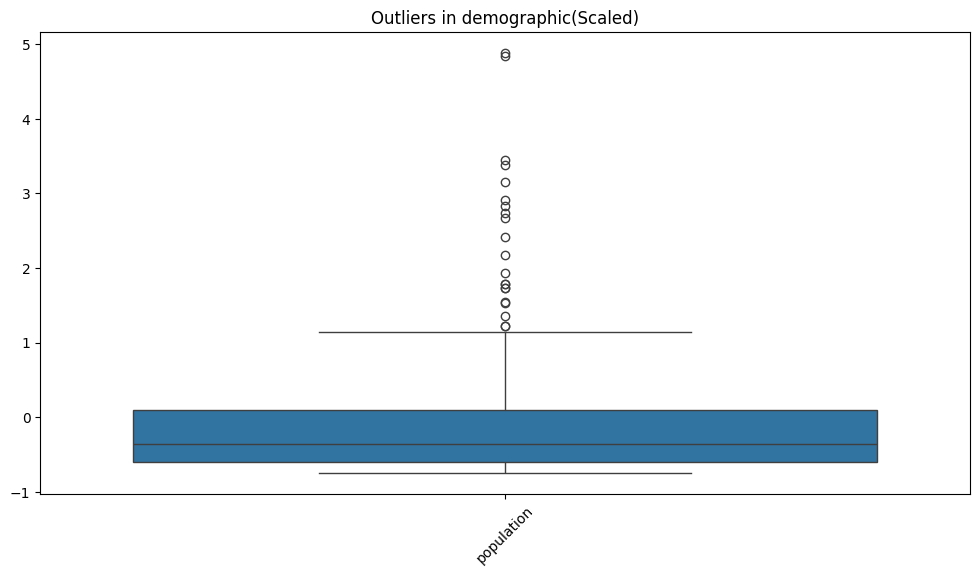

In [ ]:
'''
df2.boxplot(figsize=(12,6))
plt.title("Outliers in Covid_de")
plt.xticks(rotation=45)
plt.show()
'''
#scaled version for df2
num_df2 = df2.select_dtypes(include=['number'])
scaled = StandardScaler().fit_transform(num_df2)

plt.figure(figsize=(12,6))
sns.boxplot(data=pd.DataFrame(scaled, columns=num_df2.columns))
plt.title("Outliers in demographic(Scaled)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
q1= df2['population'].quantile(0.25)
q3 = df2['population'].quantile(0.75)
IQR = q3-q1
lower = q1-1.5 * IQR
upper = q3+1.5 * IQR

outliers = df2[(df2['population']<lower) | (df2['population'] > upper)]
#print(f"\tlower:{lower}")
#print(f"\tupper:{upper}")
#print(f"\toutlier count:{outliers}")
print(f"Percentage of total outliers: {(len(outliers)/len(df2)) * 100}")


#print(outliers[['state', 'gender', 'age_group', 'population']].sort_values('population', ascending=False).to_string())

Percentage of total outliers: 10.9375


In [ ]:
q1= df2['population'].quantile(0.25)
q3 = df2['population'].quantile(0.75)
IQR = q3-q1
upper = q3+1.5 * IQR

outlier_rows = df2[df2['population']>upper]
total_outliers = len(outlier_rows)

print("Percentage of Outliers by State: ")
print((outlier_rows['state'].value_counts()/total_outliers * 100).round(2))

print("Percentage of Outliers by Age Group: ")
print((outlier_rows['age_group'].value_counts()/total_outliers * 100).round(2))

print("Percentage of Outliers by Gender: ")
print((outlier_rows['gender'].value_counts()/total_outliers * 100).round(2))



Percentage of Outliers by State: 
state
Bayern                 28.57
Nordrhein-Westfalen    28.57
Baden-Wuerttemberg     23.81
Hessen                  9.52
Niedersachsen           9.52
Name: count, dtype: float64
Percentage of Outliers by Age Group: 
age_group
35-59    47.62
15-34    28.57
60-79    23.81
Name: count, dtype: float64
Percentage of Outliers by Gender: 
gender
female    52.38
male      47.62
Name: count, dtype: float64


Denser states accounted for majority of the population outliers reflecting greater spread/virality in larger populations.

Age group follows df1 in that the largest age group in Germany falls in the 35-59 range so naturally more cases would be detected from the majority class.

Gender is perfectly split.

**Keeping outliers in datasets but why?**

Sometimes it’s best to keep outliers in your data. They can capture valuable information that is part of your study area. Retaining these points can be hard, particularly when it reduces statistical significance! However, excluding extreme values solely due to their extremeness can distort the results by removing information about the variability inherent in the study area. You’re forcing the subject area to appear less variable than it is in reality.

If outlier in question is NATURAL part of population you are studying, you should NOT remove it

Must be able to attribute a specific caues for removing outliers

Here, outliers aren't caused by measurement errors, data entry mistakes or equipment issues (at least what we know of). High cases could be attributed to densly populated regions (disease would spread faster and overwhelm healtcares systems easily). Age demogrpahic of an area is a big factor (older people are suseptible to infection), slow government action to covid waves.

In [ ]:
# df1 gender: converting (F, M) into (female, male)

df1['gender'] = df1['gender'].map({'F': 'female', 'M': 'male'})

print(df1['gender'].unique())
print(df2['gender'].unique())

['female' 'male']
['female' 'male']


In [ ]:
print(list(df1.columns))
print(list(df2.columns))

['state', 'county', 'age_group', 'gender', 'date', 'cases', 'deaths', 'recovered']
['state', 'gender', 'age_group', 'population']


In [ ]:
merged = pd.merge(df1, df2, on=['state', 'gender', 'age_group'])

In [ ]:
#fixing distribution of population(highly skewed ) with log and sqrt
merged['population_log'] = np.log1p(merged['population'])

merged['pop_sqrt'] = np.sqrt(merged['population'])

# verify skew reduction
print(f"Population skew before: {skew(merged['population']):.2f}")
print(f"Population skew after log: {skew(merged['population_log']):.2f}")
print(f"Population skew after sqrt: {skew(merged['pop_sqrt']):.2f}")

Population skew before: 0.91
Population skew after log: -0.55
Population skew after sqrt: 0.31


Sqrt shapes the distribution of population closer to 0 compared tao the previous positive skew and log negative skew

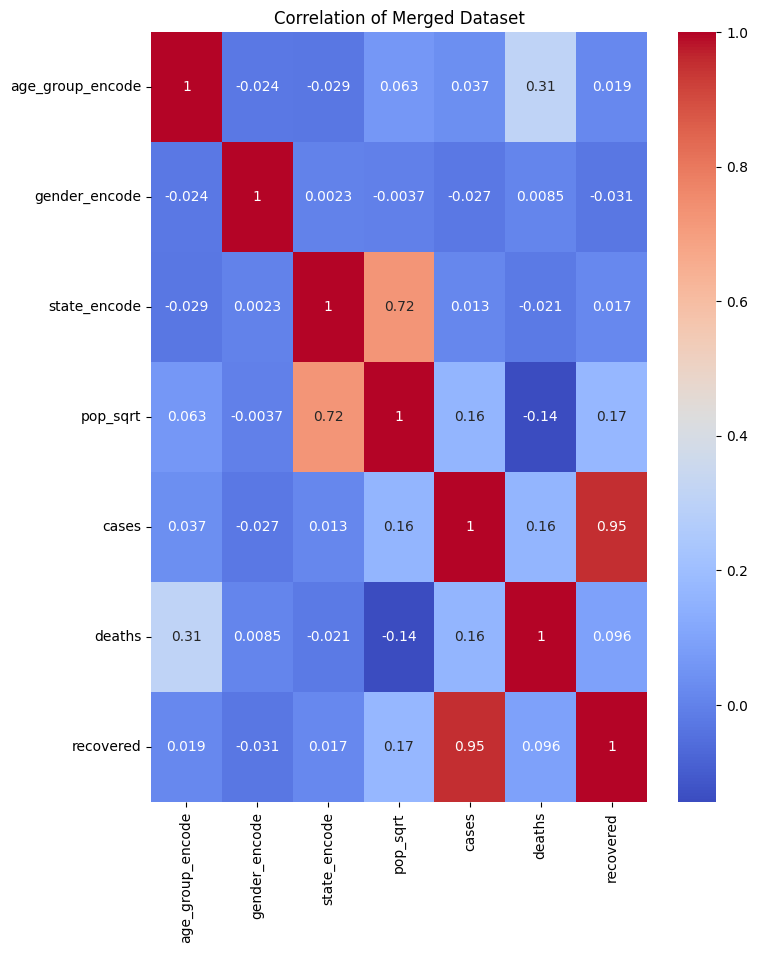

In [ ]:
#encoding string values of features age_group, state, country, gender, pop
encoder = LabelEncoder() #ordinality
age_order = {'00-04':0, '05-14':1, '15-34':2, '35-59':3, '60-79':4, '80-99':5}
merged['age_group_encode'] = merged['age_group'].map(age_order)
#merged['age_group_encode'] = encoder.fit_transform(merged['age_group'])
merged['gender_encode'] = encoder.fit_transform(merged['gender'])


#mean value of feature column (no ordinality between states/countries)
state_mean = merged.groupby('state')['population'].mean()
merged['state_encode'] = merged['state'].map(state_mean)


corr_features = ['age_group_encode', 'gender_encode', 'state_encode', 'pop_sqrt', 'cases', 'deaths', 'recovered']
corr_matrix = merged[corr_features].corr()

plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation of Merged Dataset')
plt.show()

Highly correlated features:
- cases and recovered (more cases lead to recoverd)
- population and state (possible multicollinearity)
- age_group and deaths (older age groups increase mortality)

Mildly correlated features:
- population and deaths
- cases and population
- deaths and recovered

Weakly correlated features:
- age group and cases
- gender with other feature values(does not hold large predictive power)

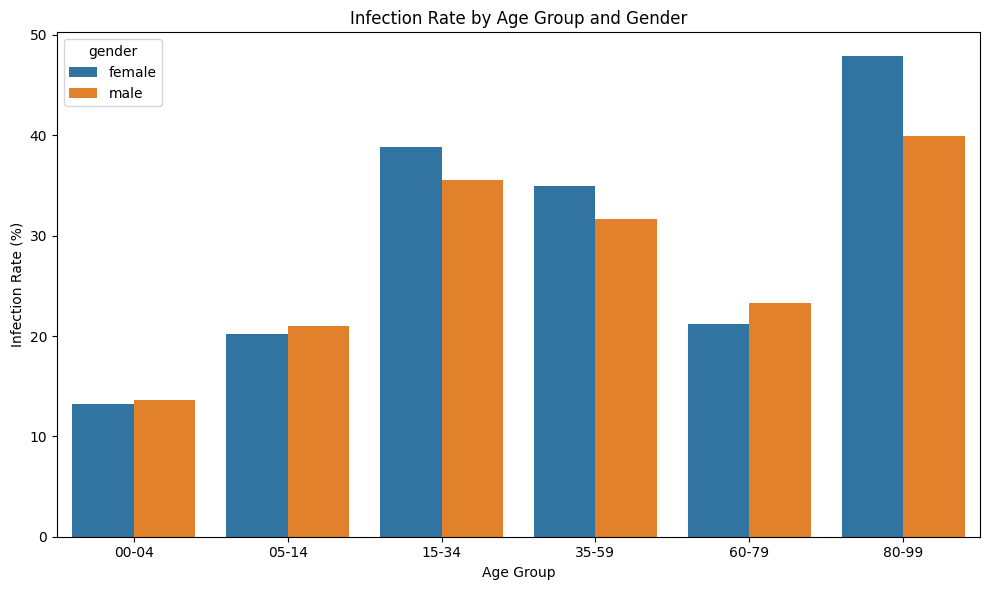

In [ ]:
cases = merged.groupby(['age_group', 'gender'])['cases'].sum()
pop = merged.groupby(['age_group', 'gender'])['population'].mean()

age_gender = (cases / pop * 100).reset_index()
age_gender.columns = ['age_group', 'gender', 'infection_rate']

plt.figure(figsize=(10, 6))
sns.barplot(data=age_gender, x='age_group', y='infection_rate', hue='gender')
plt.title('Infection Rate by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Infection Rate (%)')
plt.tight_layout()
plt.show()

**Which age/gender group has the highest covid positive cases?**

The 80-99 age group showed the highest infection rate for both genders (females: ~48%, males: ~40%). Females consistently shows higher infection rates than males in most age groups. 60-79 age group showed less infection rate compared to 15-34 and 35-59 -->> it is possibly due to the elderly being more cautious than younger age group.

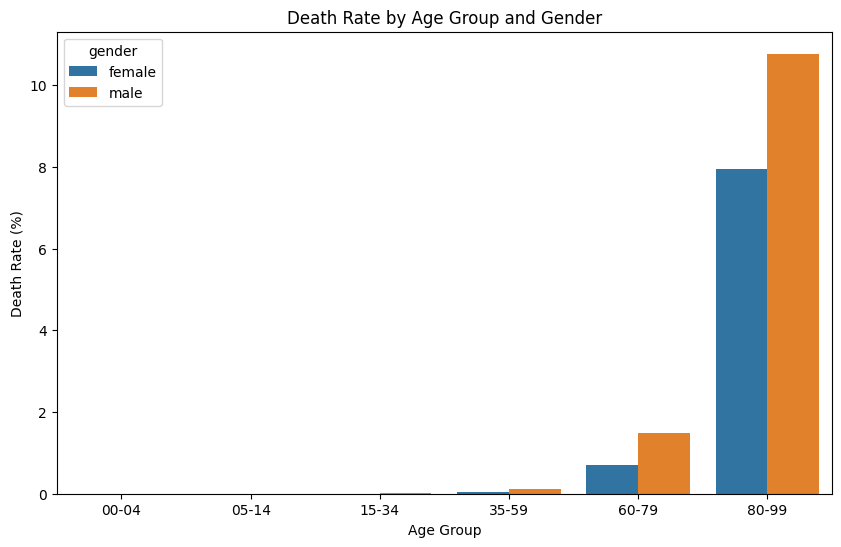

In [ ]:
deaths = merged.groupby(['age_group', 'gender'])['deaths'].sum()

age_gender_death = (deaths / pop * 100).reset_index()
age_gender_death.columns = ['age group', 'gender', 'death rate (%)']

plt.figure(figsize=(10,6))
sns.barplot(data=age_gender_death, x = 'age group', y = 'death rate (%)', hue = 'gender')
plt.title('Death Rate by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Death Rate (%)')
plt.show()

**Which age/gender group has the highest covid death cases?**

Covid death rate increases exponentially with age. It is nearly flat from 00 to 34, then start increases from 35-59, then increases dramatically at 80-99 age group. Younger age group (00-34) shows almost 0% death rate -->> it indicates they are in low risk of death outcomes from Covid.

Unlike Covid infection rate where female were higher, death rate shows male were more likely to die from Covid.

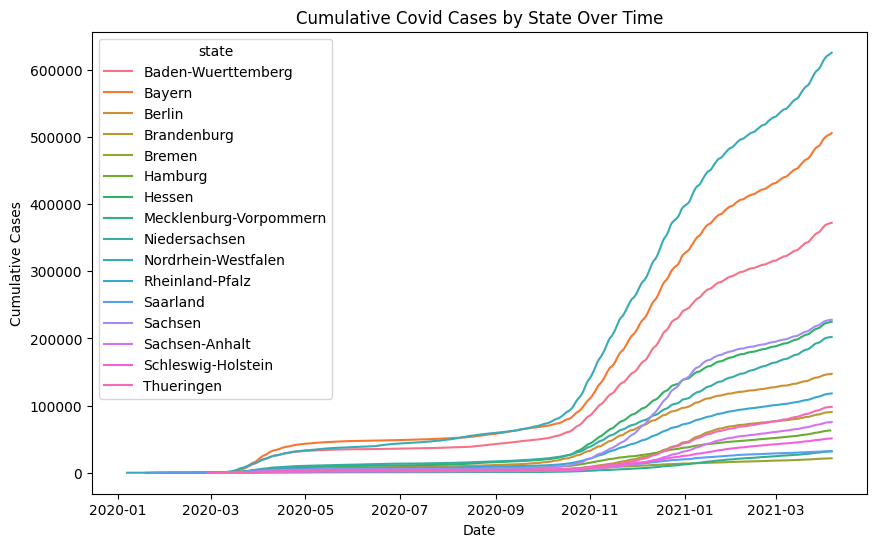

In [ ]:
state_daily_cases = df1.groupby(['state', 'date'])['cases'].sum().reset_index()
state_daily_cases['cumulative_cases'] = state_daily_cases.groupby('state')['cases'].cumsum()

plt.figure(figsize=(10,6))
sns.lineplot(data = state_daily_cases, x = 'date', y = 'cumulative_cases', hue = 'state')
plt.title('Cumulative Covid Cases by State Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Cases')
plt.show()

**What is the covid case trend in Germany?**

The covid case rate is a curve pattern. At the beginning it was stable then the curve is constant after initial increase during april/may 2020 and then again in september/october 2020.

**How is it different from each state?**

Each state shows the wave pattern, some are faster/slower than the others.

**Which state has the highest/lowest increasing rate?**

- Nordrhein-Westfalen has the fastest covid cases growth among all the states.
- Bremen has the slowest covid cases growth over time.

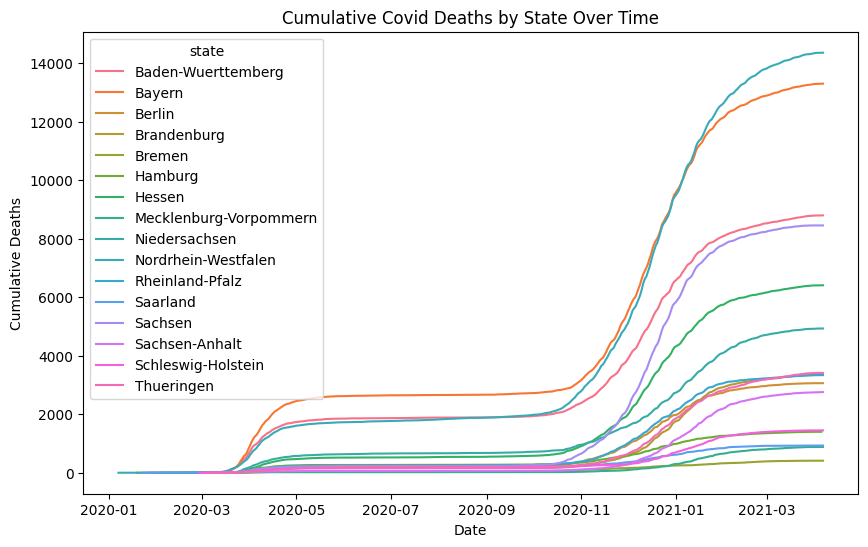

In [ ]:
state_daily_deaths = df1.groupby(['state', 'date'])['deaths'].sum().reset_index()
state_daily_deaths['cumulative_deaths'] = state_daily_deaths.groupby(['state'])['deaths'].cumsum()

plt.figure(figsize=(10,6))
sns.lineplot(data = state_daily_deaths, x = 'date', y = 'cumulative_deaths', hue = 'state')
plt.title('Cumulative Covid Deaths by State Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Deaths')
plt.show()

**What is the covid death trend in Germany?**

The covid death growth rate is a curve pattern. At the beginning it was stable then the curve is constant after initial increase during march 2020 and then again in october 2020.

**How is it different from each state?**

Each state shows a curve pattern just some are steeper than the others.

**Which state has the highest/lowest increasing rate?**

- Nordrhein-Westfalen has the fastest death rate among all the states.
- Bremen has the slowest covid death cases growth over time.

In [ ]:
# Germany Vaccination Data

vaccination = pd.read_csv('https://storage.googleapis.com/covid19-open-data/v3/vaccinations.csv')

In [ ]:
vaccination.head()

,date,location_key,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,new_vaccine_doses_administered,cumulative_vaccine_doses_administered,new_persons_vaccinated_pfizer,cumulative_persons_vaccinated_pfizer,...,new_persons_fully_vaccinated_janssen,cumulative_persons_fully_vaccinated_janssen,new_vaccine_doses_administered_janssen,cumulative_vaccine_doses_administered_janssen,new_persons_vaccinated_sinovac,total_persons_vaccinated_sinovac,new_persons_fully_vaccinated_sinovac,total_persons_fully_vaccinated_sinovac,new_vaccine_doses_administered_sinovac,total_vaccine_doses_administered_sinovac
0,2021-01-25,AD,NaN,576.0,NaN,NaN,NaN,576.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-02-01,AD,460.0,1036.0,NaN,NaN,460.0,1036.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-02-10,AD,255.0,1291.0,NaN,NaN,255.0,1291.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-02-12,AD,331.0,1622.0,NaN,NaN,331.0,1622.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-02-19,AD,519.0,2141.0,NaN,NaN,519.0,2141.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
vax_de = vaccination.dropna(subset=['location_key'])
vax_de = vax_de[vax_de['location_key'].str.startswith('DE')]
print(vax_de['location_key'].unique())

['DE' 'DE_BB' 'DE_BE' 'DE_BW' 'DE_BY' 'DE_HB' 'DE_HE' 'DE_HH' 'DE_MV'
 'DE_NI' 'DE_NW' 'DE_RP' 'DE_SH' 'DE_SL' 'DE_SN' 'DE_ST' 'DE_TH']


In [ ]:
vax_de.info()
vax_de.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 2931 entries, 318677 to 321607
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   date                                           2931 non-null   object 
 1   location_key                                   2931 non-null   object 
 2   new_persons_vaccinated                         2914 non-null   float64
 3   cumulative_persons_vaccinated                  2931 non-null   float64
 4   new_persons_fully_vaccinated                   2911 non-null   float64
 5   cumulative_persons_fully_vaccinated            2912 non-null   float64
 6   new_vaccine_doses_administered                 2914 non-null   float64
 7   cumulative_vaccine_doses_administered          2931 non-null   float64
 8   new_persons_vaccinated_pfizer                  2304 non-null   float64
 9   cumulative_persons_vaccinated_pfizer           230

,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,new_vaccine_doses_administered,cumulative_vaccine_doses_administered,new_persons_vaccinated_pfizer,cumulative_persons_vaccinated_pfizer,new_persons_fully_vaccinated_pfizer,cumulative_persons_fully_vaccinated_pfizer,...,new_persons_fully_vaccinated_janssen,cumulative_persons_fully_vaccinated_janssen,new_vaccine_doses_administered_janssen,cumulative_vaccine_doses_administered_janssen,new_persons_vaccinated_sinovac,total_persons_vaccinated_sinovac,new_persons_fully_vaccinated_sinovac,total_persons_fully_vaccinated_sinovac,new_vaccine_doses_administered_sinovac,total_vaccine_doses_administered_sinovac
count,2.914000e+03,2.931000e+03,2.911000e+03,2.912000e+03,2.914000e+03,2.931000e+03,2.304000e+03,2.304000e+03,2288.000000,2.304000e+03,...,2288.000000,2304.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,3.969835e+04,1.173376e+07,3.304049e+04,1.019206e+07,9.665638e+04,2.647876e+07,1.330783e+06,6.507796e+07,16347.516171,9.715178e+05,...,1244.329983,57924.473524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,8.809117e+04,2.164616e+07,8.680265e+04,2.058935e+07,1.933724e+05,5.451625e+07,1.648907e+06,1.017838e+08,44168.082830,1.451344e+06,...,6762.026393,112946.181856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-8.497700e+04,2.442900e+04,0.000000e+00,9.830000e+02,-8.270900e+04,2.442900e+04,2.491600e+04,2.491600e+04,-771235.000000,4.718000e+03,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.797750e+03,5.504115e+05,1.850500e+03,2.425038e+05,1.215150e+04,8.186640e+05,3.149272e+05,6.750303e+06,2978.500000,1.317948e+05,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.273550e+04,1.384537e+06,7.274000e+03,8.470295e+05,3.033600e+04,2.249120e+06,7.294605e+05,2.684653e+07,8953.500000,4.394700e+05,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.537550e+04,6.109350e+06,2.417600e+04,3.827275e+06,8.687350e+04,9.658334e+06,1.523682e+06,7.239986e+07,20994.250000,1.040423e+06,...,781.000000,66057.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.095873e+06,6.477428e+07,1.021861e+06,6.344810e+07,1.561363e+06,1.850323e+08,8.736370e+06,6.932427e+08,335940.000000,9.029087e+06,...,210971.000000,677900.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
vax_de = vax_de[['date', 'location_key', 'new_persons_vaccinated', 'cumulative_persons_vaccinated']]
vax_de.head()

,date,location_key,new_persons_vaccinated,cumulative_persons_vaccinated
318677,2020-12-27,DE,NaN,24429.0
318678,2020-12-28,DE,18007.0,42436.0
318679,2020-12-29,DE,50065.0,92501.0
318680,2020-12-30,DE,64088.0,156589.0
318681,2020-12-31,DE,49939.0,206528.0


In [ ]:
vax_de = vax_de.dropna(subset=['new_persons_vaccinated'])
vax_de['date'] = pd.to_datetime(vax_de['date'])

In [ ]:
vax = vax_de[vax_de['location_key'] == 'DE'][['date', 'cumulative_persons_vaccinated']]

In [ ]:
# death_de : number of death on each date
death_de = df1.groupby('date')['deaths'].sum().reset_index()

# vax_de : number of vaccinations on each date
vax_de = vax_de[vax_de['location_key'] == 'DE'][['date', 'cumulative_persons_vaccinated']]

# Merge death data & vaccination data
combined = pd.merge(death_de, vax_de, on='date')

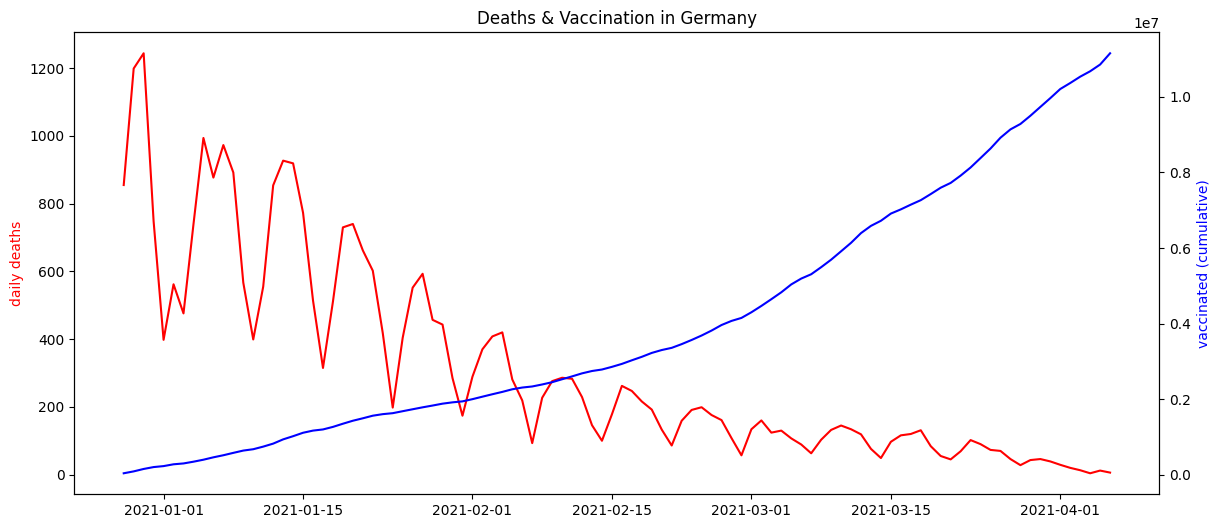

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(combined['date'], combined['deaths'], color='red', label='Daily Deaths')
ax1.set_ylabel('daily deaths', color='red')

ax2 = ax1.twinx()
ax2.plot(combined['date'], combined['cumulative_persons_vaccinated'], color='blue', label='vaccinated')
ax2.set_ylabel('vaccinated (cumulative)', color='blue')

plt.title('Deaths & Vaccination in Germany')

plt.show()

**Impact of Vaccinations on Covid in Germany**

During the period from January 2021 to April 2021, daily deaths dropped sharply over 1200 to nearly 0, while the cumulative vaccination rose to over 10 million people.

This graph clearly shows strong negative correlation between cumulative vaccinations and daily deaths. --> the vaccines may have successfully contributed to the decline in fatailities.

The repeating oscillation in daily deaths is likely due to delays of reporting deaths on weekends rather than an actual disease pattern.

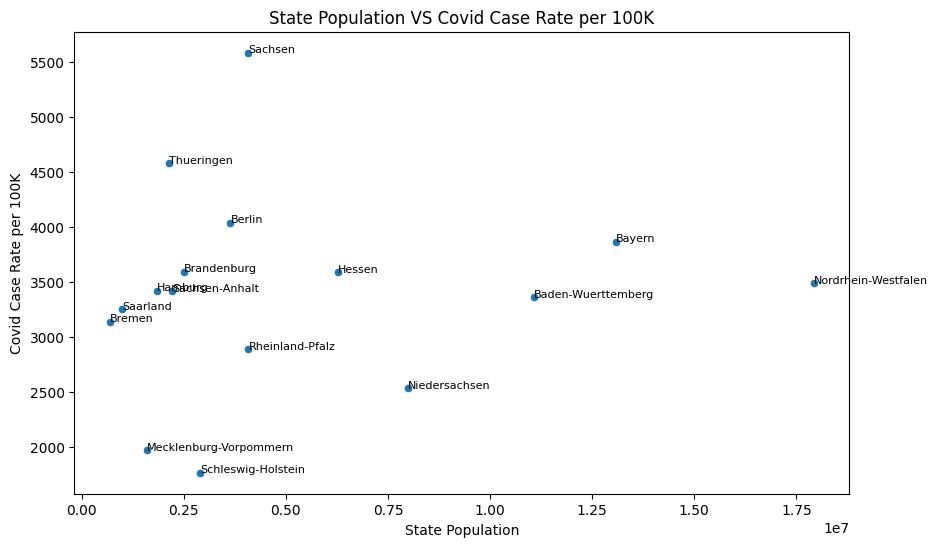

In [ ]:
state_spread_cases = df1.groupby('state')['cases'].sum().reset_index()
state_spread_pop = df2.groupby('state')['population'].sum().reset_index()
state_spread = pd.merge(state_spread_cases, state_spread_pop, on = 'state')
state_spread['case_rate_per_100k'] = (state_spread['cases']/state_spread['population']) * 100000

plt.figure(figsize=(10,6))
sns.scatterplot(data = state_spread, x = 'population', y = 'case_rate_per_100k')
for i, row in state_spread.iterrows():
    plt.annotate(row['state'], (row['population'], row['case_rate_per_100k']), fontsize = 8)
plt.title('State Population VS Covid Case Rate per 100K')
plt.xlabel('State Population')
plt.ylabel('Covid Case Rate per 100K')
plt.show()

**What contributes to the spreading of the covid cases in Germany?**

- Even though states like Sachsen and Thueringen have a smaller population, they have a high number of covid cases. While the reason for a high number of cases in Nordrhein-Westfalen is driven by its high population.
- The above strongly suggests that weather, how many people follow the rules and regulations and how they follow it matters, not just population.
- Additionally, from the other visuals it is noticeable there was a high rise in number of cases from october/november of 2020, that could be due to colder weather and people staying indoors, vaccination release so people becoming more casual about following rules, and more festivals leading to social gatherings hence more social interaction and less distancing between people.

In [ ]:
# drop 'deaths' col from data frame to predict probability of survival from available features
  #done to prevent overfitting (performing well on training data but unable to learn any patterns so it fails in the real world where the target label is not know in advance)

#feature engineering col for ratio of death:cases per region
#threshold to compare agains would be thoes who survived/recovered

#clustering algorithm = explore what feature best predicts the mortality rate of patients
#logistic regression = to use that threshold to find probability of survival
#kd-tree

In [ ]:
#X dataframe holds all predictive feature values
X = ['state_encode', 'age_group_encode', 'gender_encode', 'pop_sqrt']

print(merged[X].isnull().sum())


state_encode        0
age_group_encode    0
gender_encode       0
pop_sqrt            0
dtype: int64


In [ ]:

#1 = survived, 0=died (converting survived into binary)
merged = merged[merged['cases']>0] # case=0 is death so exclude from survived
merged['survived_ratio'] = merged['recovered']/merged['cases']


merged['survived'] = (merged['survived_ratio'] > 0.5).astype(int)

print(merged['survived'].value_counts())
print(merged['survived'].value_counts(normalize=True) * 100)

#logistic regression to predict survival of covid patient
X = merged[['age_group_encode', 'gender_encode', 'state_encode', 'population']]
y = merged['survived']


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1, class_weight='balanced')
model.fit(X_train_scaled, y_train)
probability_predictions = model.predict_proba(X_test_scaled)
l_loss = log_loss(y_test, probability_predictions)

acc_scores = accuracy_score(y_test, model.predict(X_test_scaled))

print(f"Log Loss: {l_loss}")
print(f"Accuracy scores: {acc_scores}")

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

survived
1    606309
0     69208
Name: count, dtype: int64
survived
1    89.75481
0    10.24519
Name: proportion, dtype: float64
Log Loss: 0.6489932647487912
Accuracy scores: 0.6640069872098532
              precision    recall  f1-score   support

           0       0.16      0.55      0.25     13842
           1       0.93      0.68      0.78    121262

    accuracy                           0.66    135104
   macro avg       0.55      0.61      0.52    135104
weighted avg       0.85      0.66      0.73    135104



**Before class_weight = balanced**

Log Loss: 0.31408149108296496

Accuracy scores: 0.897545594504974

**After class_weight = balanced**

Log Loss: 0.6487828473583446

Accuracy scores: 0.6640069872098532

**Loss has gotten higher** -> more error but number of false negatives have reduced as it doesn't just prioritize classifying only majority class correctly and overshadowing minority class (not survived).

In [ ]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy Scores: {cv_scores.mean()}")

y_pred_cv = cross_val_predict(model, X_train_scaled, y_train, cv=5)
print(classification_report(y_train, y_pred_cv))

Cross Validation Accuracy Scores: [0.66467437 0.66433204 0.66406373 0.65940675 0.66486557]
Mean Accuracy Scores: 0.6634684904606862
              precision    recall  f1-score   support

           0       0.16      0.55      0.25     55366
           1       0.93      0.68      0.78    485047

    accuracy                           0.66    540413
   macro avg       0.55      0.62      0.52    540413
weighted avg       0.85      0.66      0.73    540413



Model performance is consistent across training, testing and validation as seen through how the metrics after cross validation remained the same.

In [ ]:
#Model 2 - Random Forest

rf_model = RandomForestClassifier(n_estimators = 100, class_weight='balanced', random_state = 42)
rf_model.fit(X_train_scaled, y_train)
rf_prob_predictions = rf_model.predict_proba(X_test_scaled)
rf_l_loss = log_loss(y_test, rf_prob_predictions)

rf_acc_scores = accuracy_score(y_test, rf_model.predict(X_test_scaled))

print(f"Log Loss: {rf_l_loss}")
print(f"Accuracy scores: {rf_acc_scores}")

rf_y_pred = rf_model.predict(X_test_scaled)
print(classification_report(y_test, rf_y_pred))

Log Loss: 0.6376669527552539
Accuracy scores: 0.7054491354808148
              precision    recall  f1-score   support

           0       0.18      0.53      0.27     13842
           1       0.93      0.73      0.82    121262

    accuracy                           0.71    135104
   macro avg       0.56      0.63      0.54    135104
weighted avg       0.85      0.71      0.76    135104



**Before class_weight = balanced**

Log Loss: 0.31012937401396196

Accuracy scores: 0.897545594504974

**After class_weight = balanced**

Log Loss: 0.6376669527552539

Accuracy scores: 0.7054491354808148

**Loss has gotten higher** -> balancing majority class while not overshawdowing the minority class (not survived) reduces the accuracy (from 89% down to 70%), but random forest has higher accuracy rate than Logistic Regression (70% vs 66%) and a better f1-score.

In [ ]:
rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv = 5, scoring = 'accuracy')
print(f"Cross Validation Accuracy Scores: {rf_cv_scores}")
print(f"Mean Accuracy Scores: {rf_cv_scores.mean()}")

rf_y_pred_cv = cross_val_predict(rf_model, X_train_scaled, y_train, cv = 5)
print(classification_report(y_train, rf_y_pred_cv))

Cross Validation Accuracy Scores: [0.69936993 0.69942544 0.69404994 0.70473344 0.70080124]
Mean Accuracy Scores: 0.699675999990168
              precision    recall  f1-score   support

           0       0.18      0.54      0.27     55366
           1       0.93      0.72      0.81    485047

    accuracy                           0.70    540413
   macro avg       0.55      0.63      0.54    540413
weighted avg       0.85      0.70      0.76    540413



Random Forest's cross validation scores are mostly identical to the model results, showing that the random forest model is consistent and isn't overfitting to the training data.

In [ ]:
# Model 3 - kd-trees

knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

knn_y_pred = knn_model.predict(X_test_scaled)
knn_ll = log_loss(y_test, knn_model.predict_proba(X_test_scaled))
knn_acc = accuracy_score(y_test, knn_y_pred)

print(f"Log Loss: {knn_ll}")
print(f"Accuracy: {knn_acc}")
print(classification_report(y_test, knn_y_pred))


Log Loss: 2.160970268895451
Accuracy: 0.8897515987683562
              precision    recall  f1-score   support

           0       0.33      0.07      0.12     13842
           1       0.90      0.98      0.94    121262

    accuracy                           0.89    135104
   macro avg       0.61      0.53      0.53    135104
weighted avg       0.84      0.89      0.86    135104



**KNN with kd-tree (default settings, no class imbalance handling)**

Log loss: 2.160970268895451

Accuracy: 0.8897515987683562


Unlike Logistic Regression and Random Forest, KNN has no built-in method for handling class imbalance, that results in high accuracy to 89%, but very low score for minority class (not survived) at 0.07 --> the model correctly identifies only 7% of patients who did not survive, misclassifying the remaining 93% as survived(false negatives).


The log loss of 2.16 is significantly higher than the other two models (0.65, 0.64) --> kd-tree's probability estimates is unreliable.

In [ ]:
knn_cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross Validation Accuracy Scores: {knn_cv_scores}")
print(f"Mean Accuracy Scores: {knn_cv_scores.mean()}")

knn_y_pred_cv = cross_val_predict(knn_model, X_train_scaled, y_train, cv=5)
print(classification_report(y_train, knn_y_pred_cv))

Cross Validation Accuracy Scores: [0.89755096 0.88769742 0.89625566 0.89341426 0.8892415 ]
Mean Accuracy Scores: 0.8928319581354355
              precision    recall  f1-score   support

           0       0.33      0.04      0.08     55366
           1       0.90      0.99      0.94    485047

    accuracy                           0.89    540413
   macro avg       0.61      0.52      0.51    540413
weighted avg       0.84      0.89      0.85    540413



KNN's cross validation results are consistent with the test results, showing the accuracy of 89.3% --> this indicates that the model generalizes well and is not overfitting.

However, the model performs poorly on the minority class because of the severe class imbalance, performing only 4% recall for deceased patients.

Overall, the cross validation confirms that KNN consistently struggles to identify the minority class.

# Comparing all 3 models

- Random Forest is the best overall model. It has the highest accuracy amonst the 3 models (70%) and lowest log loss (0.64), meaning its probability estimate is most reliable. By using class_weight='balanced', the model handles imbalance better, hence has the highest minority class (not survived) f1-score (0.27).
- KNN has the highest accuracy (89%) since it does not have a built-in method for handling class imbalance, causing it to predict the majority class (survived) almost every time. The minority class f1-score of only 0.07 confirms this, making it the weakest model for this task despite its high overall accuracy.
- Logistic Regression's accuracy score (66.4%) is lower than the other two models, however it handles class imbalance better than KNN because of class_weight='balanced', which prevents it from simply predicting the majority class every time. The minority class f1-score of 0.25 confirms this, making it more reliable than KNN for prediction despite its lower overall accuracy.

# Contributions to the Project
**Sharon Benard**
- Cleaning
- Model 1: Logistic Regression

**Nayonika Singla**
- EDA: Case Growth Rate by State, Death Growth Rate by State, What Contributed to the Spread?
- Model 2: Random Forest

**Yoobin Chang**
- EDA: Infection Rate by Age Group and Gender, Death Rate by Age Group and Gender, Impact on Vaccinations on Covid in Germany
- Model 3: KNN (kd-tree)

# Summary
- Data preprocessing included dropping missing values in age_group(0.32%) and gender(2.01%) as both categorical features did not require NaN imputation. Boxplots and IQR scores were used to identify outliers across numeric columns in dataset 1(cases, deaths, recovered) and dataset 2(population). The outliers were retained as 25% of df1 and 10% of df2 consisted of outliers. Categorical features were encoded before modeling. Feature scaling was used to transform the skewed distribution of 'population' and features were normalized prior to training. A correlation matrix was used to examine relationships between demographic features and outcome variables.
- The covid cases growth rate is a curve pattern, for all states. At the beginning it was stable then the case growth rate is constant after initial increase of deaths after april of 2020, then again rose in september of 2020. Nordrhein-Westfalen has the highest number of deaths, while Bremen has the lowest.
- The covid death cases growth rate is a curve pattern, for all states. At the beginning it was stable then the death rate is constant after initial increase of deaths after march of 2020, then again in october of 2020. Nordrhein-Westfalen has the highest number of deaths, while Bremen has the lowest.
- Population alone is not the driver of increasing number of covid cases, there are other reasons such as, weather, whether or not people are following the rules and regulations and to what capacity they are following them, festival season, social getherings, etc.
- The Covid infection rates and death rates varied strongly by the age groups and gender. Older age groups, especially over 80+, showed the highest death rates, while gender differences were smaller but still visible, with males generally showing higher risk than females.
- Vaccination had a strong impact on Covid outcomes. As cumulative vaccinations increased from early 2021, daily deaths generally decreased, suggesting that higher vaccination coverage helped reduce severe outcomes and fatalities.
- Logistic Regression was used to classify whether a demographic group would surivie covid or not. It produced the lowest accuracy score of 66%
- Random Forest was the strongest and most reliable model (70% accuracy and f1-score = 0.27), better than Logistic Regression (66% accuracy and f1-score = 0.25) and KNN (89% accuracy (highest accuracy) and f1-score = 0.07). All three models showed consistent results under cross-validation, proving none are overfitting to the training data.